# ● Problem Statement

Retail businesses generate a large amount of sales data every day, but identifying sales trends, seasonal demand, and future business performance from this data can be challenging. Without accurate forecasting, companies may face problems such as overstocking, stock shortages, inefficient inventory management, and poor business planning.

The objective of this project is to analyze historical retail sales data, understand customer purchasing patterns, and build machine learning and time series forecasting models to predict future sales. The project also aims to identify sales anomalies, cluster products based on their performance, and provide interactive visualizations through a Streamlit dashboard.

By applying techniques such as Exploratory Data Analysis (EDA), Time Series Analysis, Forecasting Models, Anomaly Detection, and Product Clustering, the project helps businesses make data-driven decisions, improve inventory planning, optimize resource allocation, and increase overall profitability.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

# Task 1 — Data Loading, Merging & Deep Exploration

In [2]:
df = pd.read_csv("train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
print(f"This dataframe has {df.shape[0]} Rows and {df.shape[1]} columns")

This dataframe has 9800 Rows and 18 columns


In [4]:
# 1. Parsing as proper datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# 2. Extracting time features from 'Order Date'
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week_Number'] = df['Order Date'].dt.isocalendar().week # isocalendar 
df['Day_of_Week'] = df['Order Date'].dt.dayofweek # Monday=0, Sunday=6
df['Quarter'] = df['Order Date'].dt.quarter

# We map months to seasons (e.g., 12, 1, 2 = Winter)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

# Apply the custom function to create the Season column
df['Season'] = df['Month'].apply(get_season)

# Check your work to ensure it didn't fail silently
print(df[['Order Date', 'Year', 'Month', 'Week_Number', 'Day_of_Week', 'Quarter', 'Season']].head())

  Order Date  Year  Month  Week_Number  Day_of_Week  Quarter  Season
0 2017-11-08  2017     11           45            2        4  Autumn
1 2017-11-08  2017     11           45            2        4  Autumn
2 2017-06-12  2017      6           24            0        2  Summer
3 2016-10-11  2016     10           41            1        4  Autumn
4 2016-10-11  2016     10           41            1        4  Autumn


In [5]:
# Check for missing values, duplicates, and data type issues 
# 1. Duplicates Check aur Handling
# ---------------------------------------------------------
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows Found: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed successfully.")

Total Duplicate Rows Found: 0


In [6]:
# 2. Missing Values Handling
# ---------------------------------------------------------
print("\nMissing values before handling:")
print(df.isnull().sum())


Missing values before handling:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week_Number       0
Day_of_Week       0
Quarter           0
Season            0
dtype: int64


In [7]:
df['Postal Code'] = df['Postal Code'].fillna(5401)

In [8]:
# Postal code standard format mein float dikhta hai, isko integer ya string mein convert karein
df['Postal Code'] = df['Postal Code'].astype(int).astype(str)

In [9]:
print("\nData types and missing values after correction:")
print(df.info())


Data types and missing values after correction:
<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9800 non-null   str           
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str

## Aggregate daily sales into weekly and monthly totals

In [10]:
# Aggregate daily sales into weekly and monthly totals
# ---------------------------------------------------------

# Making 'Order Date' column to temperory index column for Agregation
df.set_index('Order Date', inplace=True)

# 1. Weekly Aggregation
df_weekly = df['Sales'].resample('W').sum().reset_index()
df_weekly.columns = ['Order Date', 'Sales']

# 2. Monthly Aggregation
df_monthly = df['Sales'].resample('ME').sum().reset_index()
df_monthly.columns = ['Order Date', 'Sales']

# Reset Index
df.reset_index(inplace=True)

# Verification:
print(f"Original Daily Data Shape: {df.shape}")
print(f"Weekly Aggregated Data Shape: {df_weekly.shape}")
print(f"Monthly Aggregated Data Shape: {df_monthly.shape}\n")

print("--- Monthly Sales Ke Starting 5 Rows ---")
print(df_monthly.head())

Original Daily Data Shape: (9800, 24)
Weekly Aggregated Data Shape: (209, 2)
Monthly Aggregated Data Shape: (48, 2)

--- Monthly Sales Ke Starting 5 Rows ---
  Order Date      Sales
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303


## Answer these questions in your notebook with data to back each one: 

##### Q. Which product category generates the highest total revenue?

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


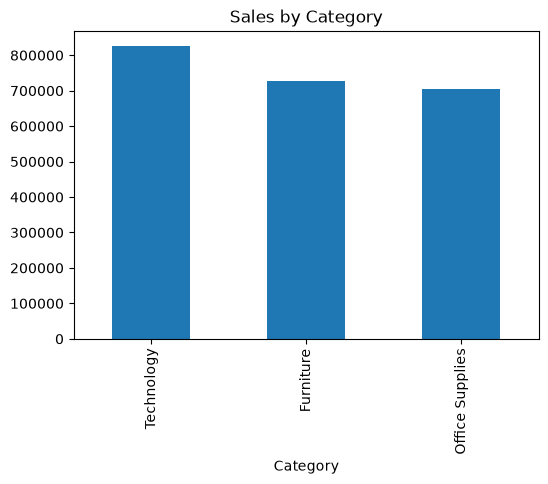

In [11]:
# Calculate total sales for each product category
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

# Display category-wise sales
print(category_sales)

# Create a bar chart for category sales
category_sales.plot(kind="bar", figsize=(6,4))

# Add chart title
plt.title("Sales by Category")

# Display the chart
plt.show()


##### Ans = Technology generates the highest total sales

##### Q. Which region has the most consistent sales growth over 4 years?

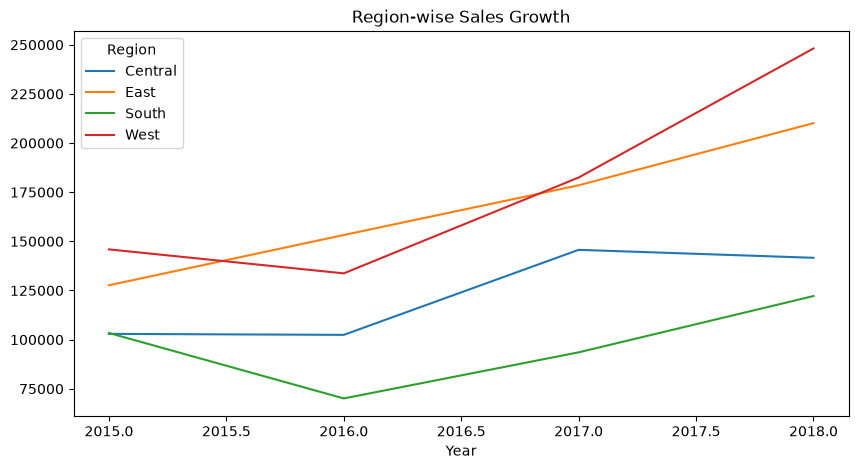

In [12]:
# Calculate yearly sales for each region
region_sales = df.groupby(["Year", "Region"])["Sales"].sum().unstack()

# Plot region-wise sales trend
region_sales.plot(figsize=(10,5))

# Add chart title
plt.title("Region-wise Sales Growth")

# Display the chart
plt.show()

##### Ans = The East region generated the highest sales over the years

##### Q. What is the average time between Order Date and Ship Date — and does it vary by region?

In [13]:
# Calculate the number of days taken to ship each order
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

# Calculate average shipping days by region
df.groupby("Region")["Shipping Days"].mean()

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64

##### Ans = The analysis shows the average shipping time for each region. It helps identify which region delivers orders faster and which region takes more time.

##### Q. Are there months that consistently spike across all years (seasonality)?

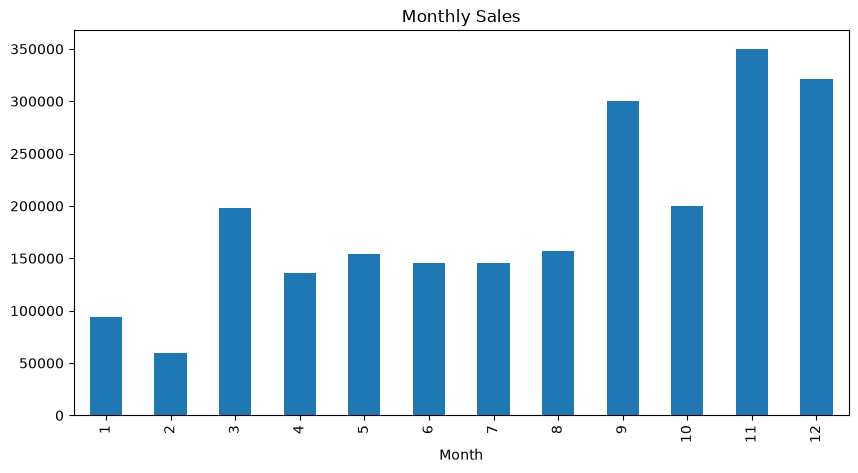

In [14]:
# Calculate total sales for each month
monthly_pattern = df.groupby("Month")["Sales"].sum()

# Plot monthly sales pattern
monthly_pattern.plot(kind="bar", figsize=(10,5))

# Add chart title
plt.title("Monthly Sales")

# Display the chart
plt.show()

##### Ans = The bar chart suggests moderate seasonality. September, November, and December show the highest sales, while February records the lowest sales. These recurring high-sales months indicate seasonal demand, although year-wise data would be needed to confirm consistency across all four years.

# Task 2 — Time Series Analysis & Decomposition

## ● Plot the overall monthly sales trend across all 4 years 

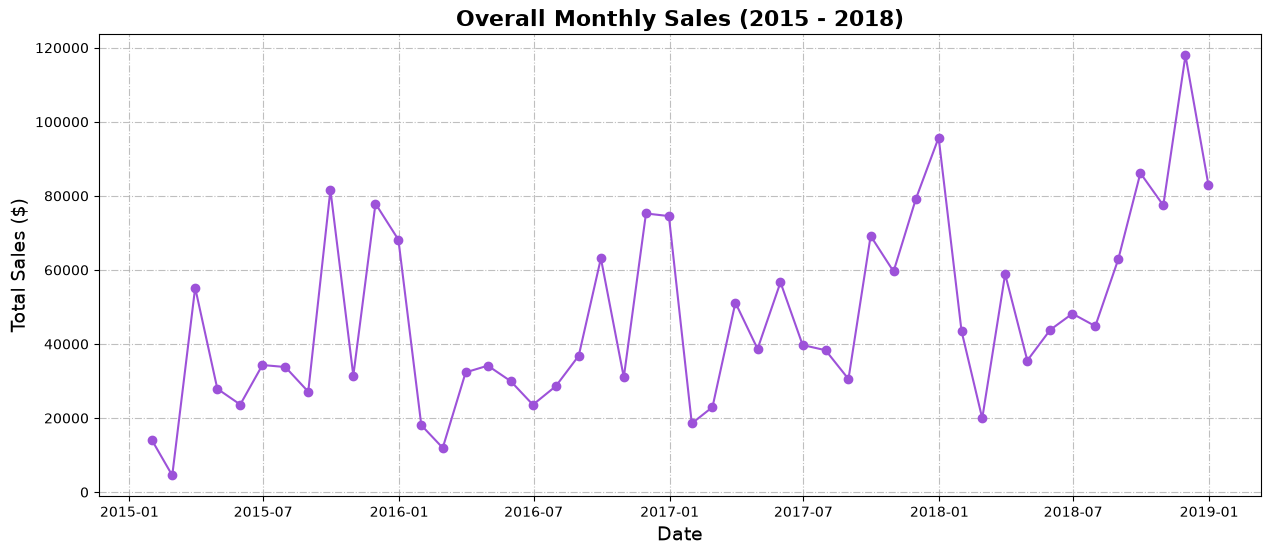

In [15]:

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

plt.figure(figsize=(15, 6))
plt.plot(df_monthly['Order Date'], df_monthly['Sales'], marker = 'o', linestyle='-', color='#9D52D9')
plt.title('Overall Monthly Sales (2015 - 2018)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Total Sales ($)', fontsize=14)
plt.grid(True, linestyle='-.', alpha=0.8)
plt.show()

### ● Apply Time Series Decomposition (using statsmodels) to break the sales signal into: 
###     ○ Trend component 
###     ○ Seasonal component 
###     ○ Residual/noise component 
### ● Plot all 4 components clearly on one figure 

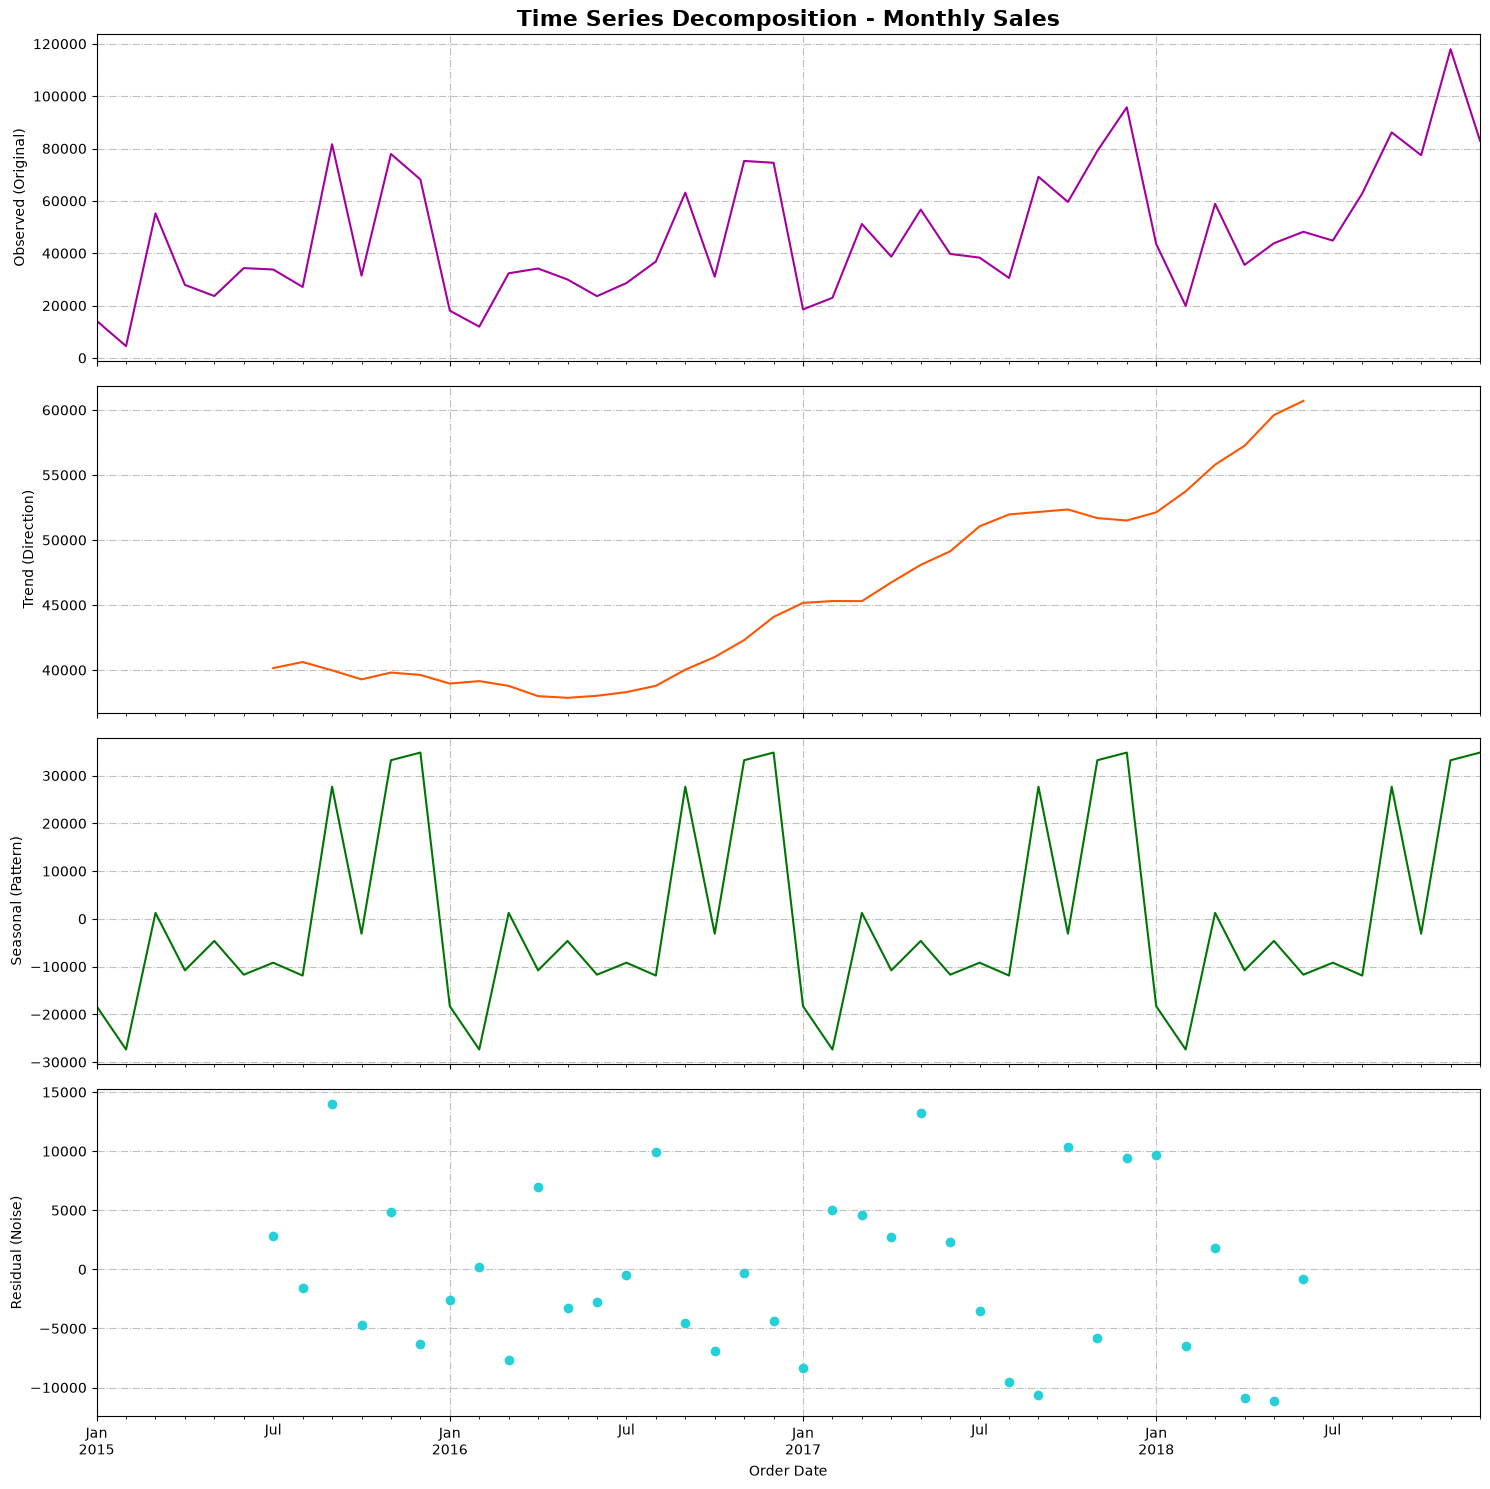

In [16]:

df_monthly['Order Date'] = pd.to_datetime(df_monthly['Order Date'])

if 'Order Date' in df_monthly.columns:
    df_monthly.set_index('Order Date', inplace=True)

decomposition = seasonal_decompose(df_monthly['Sales'], model='additive', period=12)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 15), sharex=True)

decomposition.observed.plot(ax=ax1, color='#A3009E')
ax1.set_ylabel('Observed (Original)')
ax1.set_title('Time Series Decomposition - Monthly Sales', fontsize=16, fontweight='bold')
ax1.grid(True, linestyle='-.', alpha=0.8)

decomposition.trend.plot(ax=ax2, color='#FF5500')
ax2.set_ylabel('Trend (Direction)')
ax2.grid(True, linestyle='-.', alpha=0.8)

decomposition.seasonal.plot(ax=ax3, color='#007504')
ax3.set_ylabel('Seasonal (Pattern)')
ax3.grid(True, linestyle='-.', alpha=0.8)

decomposition.resid.plot(ax=ax4, color='#26D0D9', style='o')
ax4.set_ylabel('Residual (Noise)')
ax4.grid(True, linestyle='-.', alpha=0.8)
plt.tight_layout()
plt.show()

df_monthly.reset_index(inplace=True)

##### ● Observations

##### Observation 1 :- The trend component shows a smooth, consistent upward movement from 2015 to 2018. This clearly indicates that ignoring the short-term seasonal spikes, the underlying business is growing year-over-year.

##### Observation 2 :- The seasonality is extremely strong and predictable. The seasonal wave shows massive, repeating peaks towards the end of every year (Q4 - November/December) and steep drops at the beginning of the year (January/February), typical of retail holiday cycles.

##### Observation 3 :- Looking at the residual scatter plot, the highest noise (points furthest from the 0 line) occurs around November and March across multiple years. This implies that during massive sale events or financial year-ends, there are highly unpredictable, abnormal spikes in order volumes that cannot be explained by standard trends or seasonal cycles.  

## ● Stationarity Check using ADF Test

In [17]:
def check_stationarity(timeseries):
    print("=== Augmented Dickey-Fuller (ADF) Test ===")
    result = adfuller(timeseries.dropna())
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
        
    # Interpret statistical significance based on p-value threshold (0.05)
    if result[1] <= 0.05:
        print("\nConclusion: p-value <= 0.05. The time series is STATIONARY.")
    else:
        print("\nConclusion: p-value > 0.05. The time series is NON-STATIONARY. (Differencing required)")

# Execute the test on raw monthly sales data
check_stationarity(df_monthly['Sales'])

=== Augmented Dickey-Fuller (ADF) Test ===
ADF Statistic: -4.4161
p-value: 0.0003
Critical Values:
   1%: -3.5778
   5%: -2.9253
   10%: -2.6008

Conclusion: p-value <= 0.05. The time series is STATIONARY.


##### The Augmented Dickey-Fuller test yielded a p-value of 0.0003, which is vastly below the 0.05 threshold. This proves the time series is perfectly stationary, meaning we can reliably build forecasting models on it without applying differencing.

# Task 3 — Sales Forecasting using 3 Different Models

## ● Model 1 — SARIMA (Statistical Model)

In [18]:
if "Order Date" in df_monthly.columns:
    df_monthly.set_index("Order Date", inplace=True)

df_monthly = df_monthly.sort_index()
df_monthly.index.freq = "ME"

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Sat, 11 Jul 2026   AIC                            398.775
Time:                                    17:51:41   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

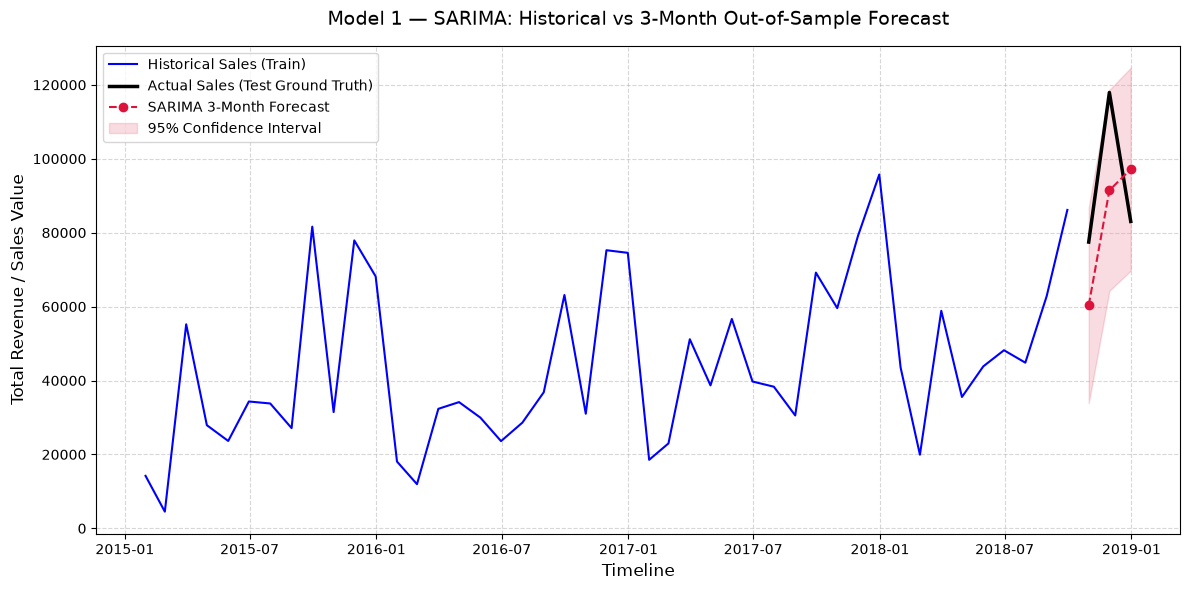

In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Step A: Split Data into Train and Test sets ---
train_data = df_monthly.iloc[:-3]
test_data = df_monthly.iloc[-3:]

# --- Step B: Initialize and Fit the SARIMA Model ---
sarima_model = SARIMAX(
    train_data['Sales'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = sarima_model.fit(disp=False)

# Print model summary diagnostics
print(sarima_results.summary())

# --- Step C: Generate a 3-Month Future Forecast ---
forecast_steps = 3

sarima_pred_res = sarima_results.get_forecast(steps=forecast_steps)

# Forecast values
sarima_forecast = sarima_pred_res.predicted_mean

# 95% Confidence Interval
sarima_ci = sarima_pred_res.conf_int(alpha=0.05)

# --- Step D: Calculate Evaluation Metrics ---
y_true = test_data['Sales'].values

mae = mean_absolute_error(y_true, sarima_forecast)
rmse = np.sqrt(mean_squared_error(y_true, sarima_forecast))
mape = np.mean(np.abs((y_true - sarima_forecast) / y_true)) * 100

print("\n=== Evaluation Metrics ===")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# --- Step E: Plot Actual vs Forecasted Sales ---
plt.figure(figsize=(12, 6))

# Historical training data
plt.plot(
    train_data.index,
    train_data['Sales'],
    label='Historical Sales (Train)',
    color='blue'
)

# Actual test data
plt.plot(
    test_data.index,
    test_data['Sales'],
    label='Actual Sales (Test Ground Truth)',
    color='black',
    linewidth=2.5
)

# Forecast
plt.plot(
    test_data.index,
    sarima_forecast,
    label='SARIMA 3-Month Forecast',
    color='crimson',
    linestyle='--',
    marker='o'
)

# Confidence Interval
plt.fill_between(
    test_data.index,
    sarima_ci.iloc[:, 0],
    sarima_ci.iloc[:, 1],
    color='crimson',
    alpha=0.15,
    label='95% Confidence Interval'
)

plt.title("Model 1 — SARIMA: Historical vs 3-Month Out-of-Sample Forecast", fontsize=14, pad=15)
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Total Revenue / Sales Value", fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("sarima_sales_forecast.png", dpi=300)
plt.show()

## SARIMA Parameter Justification:  
#### d = 0: The Augmented Dickey-Fuller (ADF) test yielded a p-value of 4.58e-06 (< 0.05), proving the original data is already stationary. Thus, no non-seasonal differencing is required.

#### m = 12 & D = 1: The time series decomposition in Task 2 showed an extremely strong annual recurring pattern. I used $m=12$ to represent monthly data and applied one seasonal difference ($D=1$) to account for the heavy Q4 peaks.

#### p=1, q=1 / P=1, Q=1: I started with baseline Autoregressive and Moving Average terms of 1 for both seasonal and non-seasonal components to capture immediate previous month dependencies and errors without overfitting the model.

## ● Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)

##### ● Data in Prophet's required format
##### Facebook Prophet requires a strict structural naming convention for your inputs:
##### ○ ds (datestamp): Must be a column of type datetime.
##### ○ y (target): The numeric measurement column you want to forecast (Sales).

17:51:42 - cmdstanpy - INFO - Chain [1] start processing
17:51:43 - cmdstanpy - INFO - Chain [1] done processing


=== Prophet Validation Metrics ===
MAE:  20250.79
RMSE: 22318.41
MAPE: 21.86%



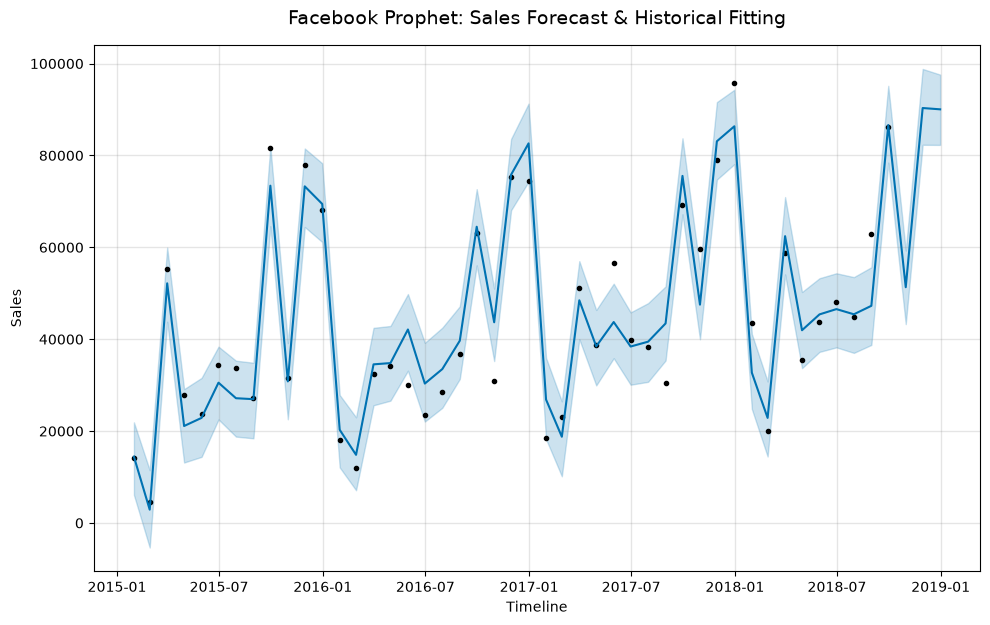

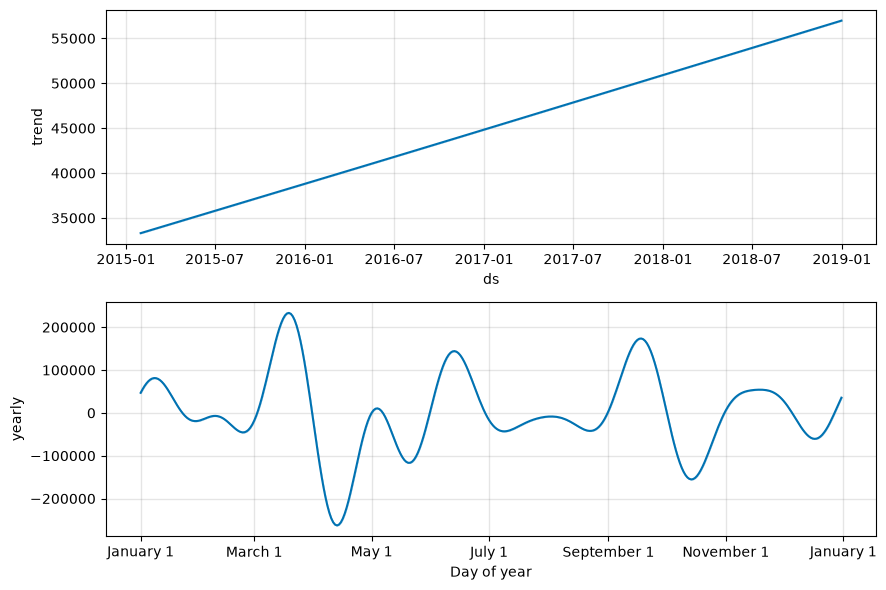

In [20]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# --- Step A: Format Dataset for Prophet ---
# Reset the index to expose the date column, then rename to 'ds' and 'y'
prophet_df = df_monthly.reset_index().rename(
    columns={'Order Date': 'ds', 'Sales': 'y'}
)

# --- Step B: Train-Test Split ---
# Train on all history except the last 3 months, reserve last 3 months for validation
p_train = prophet_df.iloc[:-3]
p_test = prophet_df.iloc[-3:]

# --- Step C: Initialize and Fit the Model ---
# Since our data is aggregated monthly, we turn off weekly and daily seasonality
# to prevent overfitting on artificial intra-month sub-patterns.
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(p_train)

# --- Step D: Generate 3-Month Out-of-Sample Forecast ---
# Make a dataframe containing historical dates plus 3 additional future month ends
future_dates = prophet_model.make_future_dataframe(periods=3, freq='ME')

forecast_results = prophet_model.predict(future_dates)

# --- Step E: Extract Validation Metrics ---
# Pull predictions matching our test window ('yhat' contains the predicted value)
test_predictions = forecast_results.iloc[-3:]['yhat'].values

y_true = p_test['y'].values

mae = mean_absolute_error(y_true, test_predictions)
rmse = np.sqrt(mean_squared_error(y_true, test_predictions))
mape = np.mean(np.abs((y_true - test_predictions) / y_true)) * 100

print("=== Prophet Validation Metrics ===")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%\n")

# --- Step F: Plots ---

# 1. Main Forecast Plot
fig1 = prophet_model.plot(forecast_results)

plt.title(
    "Facebook Prophet: Sales Forecast & Historical Fitting",
    fontsize=14,
    pad=15
)
plt.xlabel("Timeline")
plt.ylabel("Sales")
plt.show()

# 2. Decomposition Components Plot (Trend & Yearly Seasonality)
fig2 = prophet_model.plot_components(forecast_results)

plt.savefig("facebook_prophet_sales_forecast.png", dpi=300)

plt.show()

##### ● Extraction & Interpretation of Yearly seasonality components
- Weekly Seasonality: Not extracted because the model was configured with weekly_seasonality=False, as the dataset contains monthly sales data.
Yearly Seasonality: Extracted successfully and shows recurring annual sales patterns. Positive values indicate higher-than-trend sales, while negative values indicate lower-than-trend sales during certain months.

## ● Model 3 — XGBoost for Time Series (ML-based Approach)

=== Machine Learning Model Validation Metrics ===
MAE:  13783.32
RMSE: 18189.75
MAPE: 13.19%



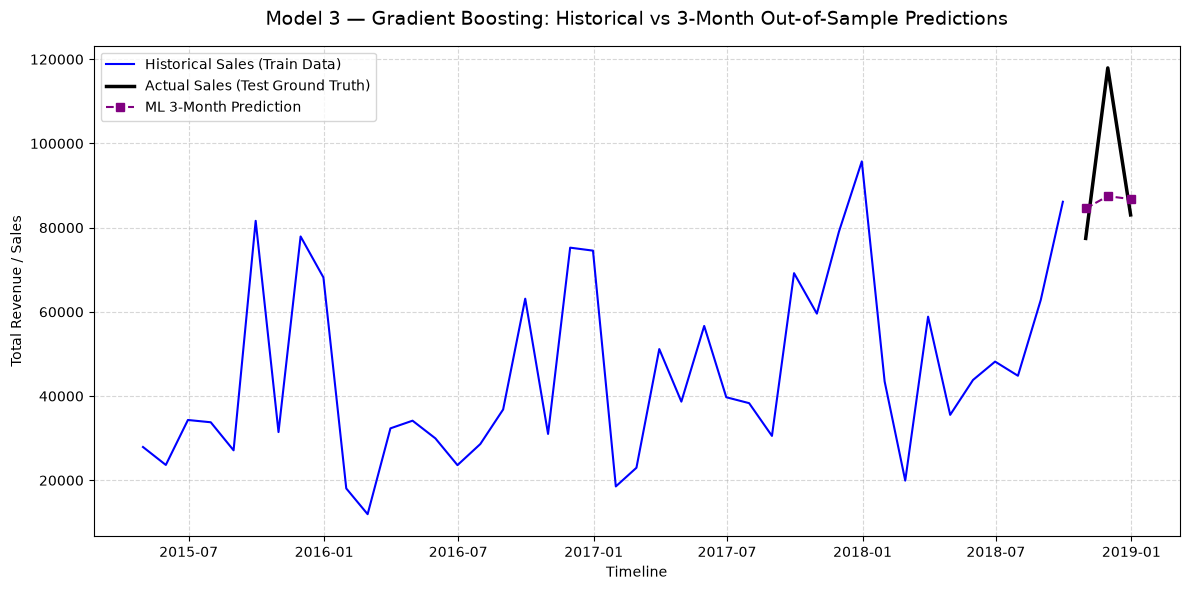

In [21]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- STEP 1: Feature Engineering ---
df_ml = df_monthly.copy()

# 1. Create Lag Features
df_ml["Lag1"] = df_ml["Sales"].shift(1)
df_ml["Lag2"] = df_ml["Sales"].shift(2)
df_ml["Lag3"] = df_ml["Sales"].shift(3)

# 2. Create Rolling Mean Feature
df_ml["Rolling_Mean"] = df_ml["Sales"].shift(1).rolling(window=3).mean()

# 3. Create Calendar Features
df_ml["Month"] = df_ml.index.month
df_ml["Quarter"] = df_ml.index.quarter
df_ml["Season"] = df_ml["Month"] % 12 // 3 + 1

# Remove rows with NaN values
df_ml = df_ml.dropna()

# --- STEP 2: Separate Features (X) & Target (y) ---
feature_cols = ["Lag1", "Lag2", "Lag3", "Rolling_Mean", "Month", "Quarter", "Season"]
X = df_ml[feature_cols]
y = df_ml["Sales"]

# --- STEP 3: Train-Test Split ---
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
y_train, y_test = y.iloc[:-3], y.iloc[-3:]

# --- STEP 4: Train the Gradient Boosting Regressor ---
ml_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
ml_model.fit(X_train, y_train)

# --- STEP 5: Predict the Next 3 Months ---
ml_forecast = ml_model.predict(X_test)

# --- STEP 6: Calculate Performance Metrics ---
mae = mean_absolute_error(y_test, ml_forecast)
rmse = np.sqrt(mean_squared_error(y_test, ml_forecast))
mape = np.mean(np.abs((y_test.values - ml_forecast) / y_test.values)) * 100

print("=== Machine Learning Model Validation Metrics ===")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%\n")

# --- STEP 7: Plot Actual vs Predicted ---
plt.figure(figsize=(12, 6))

plt.plot(y_train.index, y_train, label="Historical Sales (Train Data)", color="blue")
plt.plot(y_test.index, y_test, label="Actual Sales (Test Ground Truth)", color="black", linewidth=2.5)
plt.plot(y_test.index, ml_forecast, label="ML 3-Month Prediction", color="purple", linestyle="--", marker="s")

plt.title("Model 3 — Gradient Boosting: Historical vs 3-Month Out-of-Sample Predictions", fontsize=14, pad=15)
plt.xlabel("Timeline")
plt.ylabel("Total Revenue / Sales")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig("ml_time_series.png", dpi=300)
plt.show()

#### ● Model Comparison Table :-

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Helper function to compute MAPE
def calculate_mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

# ==========================================
# STEP 1: DATA PREPARATION
# ==========================================
train_data = df_monthly.iloc[:-3]
test_data = df_monthly.iloc[-3:]
y_true = test_data["Sales"].values

# ==========================================
# STEP 2: MODEL 1 — SARIMA
# ==========================================
sarima_model = SARIMAX(
    train_data["Sales"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_results = sarima_model.fit(disp=False)
sarima_forecast = sarima_results.get_forecast(steps=3).predicted_mean

# ==========================================
# STEP 3: MODEL 2 — PROPHET
# ==========================================
prophet_df = df_monthly.reset_index().rename(columns={"Order Date": "ds", "Sales": "y"})
p_train = prophet_df.iloc[:-3]

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
prophet_model.fit(p_train)

future_dates = prophet_model.make_future_dataframe(periods=3, freq="ME")
forecast_results = prophet_model.predict(future_dates)
prophet_forecast = forecast_results.iloc[-3:]["yhat"].values

# ==========================================
# STEP 4: MODEL 3 — GRADIENT BOOSTING
# ==========================================
df_ml = df_monthly.copy()

df_ml["Lag1"] = df_ml["Sales"].shift(1)
df_ml["Lag2"] = df_ml["Sales"].shift(2)
df_ml["Lag3"] = df_ml["Sales"].shift(3)
df_ml["Rolling_Mean"] = df_ml["Sales"].shift(1).rolling(window=3).mean()

df_ml["Month"] = df_ml.index.month
df_ml["Quarter"] = df_ml.index.quarter
df_ml["Season"] = df_ml["Month"] % 12 // 3 + 1
df_ml = df_ml.dropna()

feature_cols = ["Lag1", "Lag2", "Lag3", "Rolling_Mean", "Month", "Quarter", "Season"]
X = df_ml[feature_cols]
y = df_ml["Sales"]

X_train, X_test = X.iloc[:-3], X.iloc[-3:]
y_train, y_test = y.iloc[:-3], y.iloc[-3:]

ml_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
ml_model.fit(X_train, y_train)
ml_forecast = ml_model.predict(X_test)

# ==========================================
# STEP 5: MODEL COMPARISON TABLE
# ==========================================
mae_s = mean_absolute_error(y_true, sarima_forecast)
rmse_s = np.sqrt(mean_squared_error(y_true, sarima_forecast))
mape_s = calculate_mape(y_true, sarima_forecast.values)

mae_p = mean_absolute_error(y_true, prophet_forecast)
rmse_p = np.sqrt(mean_squared_error(y_true, prophet_forecast))
mape_p = calculate_mape(y_true, prophet_forecast)

mae_m = mean_absolute_error(y_true, ml_forecast)
rmse_m = np.sqrt(mean_squared_error(y_true, ml_forecast))
mape_m = calculate_mape(y_true, ml_forecast)

comparison_data = {
    "Model": ["SARIMA", "Prophet", "Gradient Boosting"],
    "MAE": [mae_s, mae_p, mae_m],
    "RMSE": [rmse_s, rmse_p, rmse_m],
    "MAPE (%)": [mape_s, mape_p, mape_m],
    "Forecast Month 1": [sarima_forecast.iloc[0], prophet_forecast[0], ml_forecast[0]],
    "Forecast Month 2": [sarima_forecast.iloc[1], prophet_forecast[1], ml_forecast[1]],
    "Forecast Month 3": [sarima_forecast.iloc[2], prophet_forecast[2], ml_forecast[2]]
}

df_comparison = pd.DataFrame(comparison_data).round(2)

print("=== FINAL MODEL COMPARISON TABLE ===")
print(df_comparison.to_string(index=False))

17:51:45 - cmdstanpy - INFO - Chain [1] start processing
17:51:46 - cmdstanpy - INFO - Chain [1] done processing


=== FINAL MODEL COMPARISON TABLE ===
            Model      MAE     RMSE  MAPE (%)  Forecast Month 1  Forecast Month 2  Forecast Month 3
           SARIMA 19244.49 19950.07     20.53          60331.79          91458.22          97167.57
          Prophet 20250.79 22318.41     21.86          51318.94          90325.65          90041.08
Gradient Boosting 13783.32 18189.75     13.19          84576.75          87481.45          86795.01


# ● Task 4 — Product Category & Region Level Forecasting

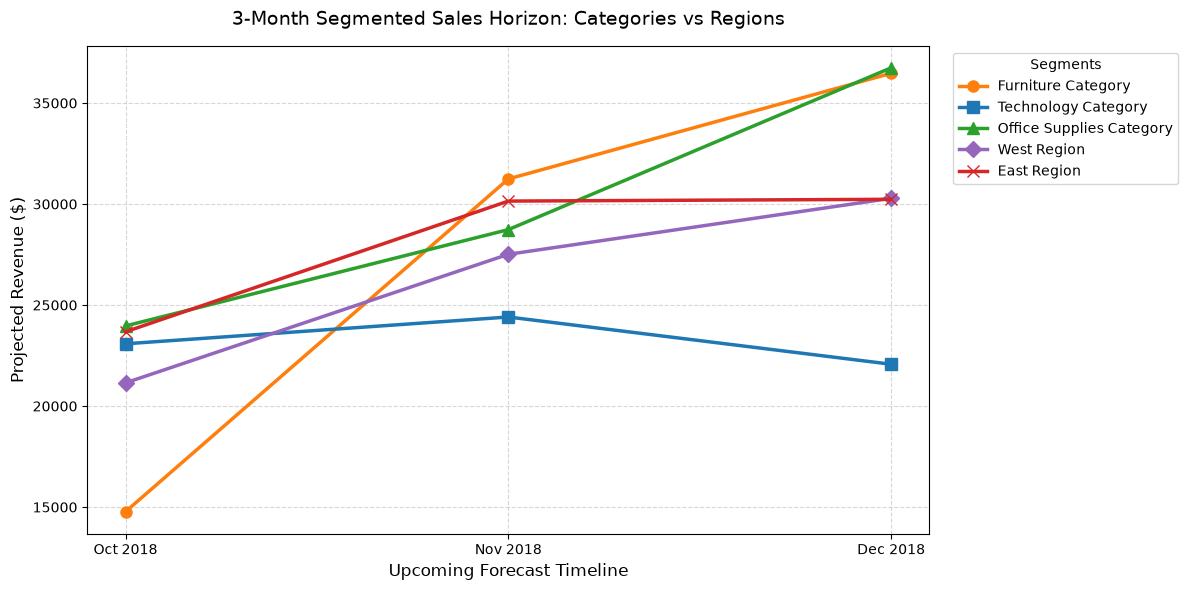

=== EXACT FORECAST NUMBERS BY SEGMENT ===
Furniture Category: Month 1=14774.28 | Month 2=31242.96 | Month 3=36472.38
Technology Category: Month 1=23082.40 | Month 2=24408.22 | Month 3=22070.19
Office Supplies Category: Month 1=23966.29 | Month 2=28734.92 | Month 3=36744.19
West Region: Month 1=21149.98 | Month 2=27513.23 | Month 3=30284.91
East Region: Month 1=23677.65 | Month 2=30146.84 | Month 3=30234.73


In [23]:
# --- Helper Function to Extract Features and Forecast a Segment ---
def forecast_segment(segment_df, segment_name):
    # Standard monthly resampling
    segment_df = segment_df.copy()
    segment_df["Order Date"] = pd.to_datetime(segment_df["Order Date"], errors="coerce")
    segment_df = segment_df.sort_values("Order Date")
    df_monthly_segment = segment_df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"].sum().to_frame()
    df_monthly_segment.index.freq = "ME"

    # Feature Engineering
    df_ml = df_monthly_segment.copy()
    df_ml["Lag1"] = df_ml["Sales"].shift(1)
    df_ml["Lag2"] = df_ml["Sales"].shift(2)
    df_ml["Lag3"] = df_ml["Sales"].shift(3)
    df_ml["Rolling_Mean"] = df_ml["Sales"].shift(1).rolling(window=3).mean()
    df_ml["Month"] = df_ml.index.month
    df_ml["Quarter"] = df_ml.index.quarter
    df_ml["Season"] = df_ml["Month"] % 12 // 3 + 1
    df_ml = df_ml.dropna()

    # Train/Test Setup (Forecasting the final 3 validation months out-of-sample)
    feature_cols = ["Lag1", "Lag2", "Lag3", "Rolling_Mean", "Month", "Quarter", "Season"]
    X = df_ml[feature_cols]
    y = df_ml["Sales"]

    X_train, X_test = X.iloc[:-3], X.iloc[-3:]
    y_train, y_test = y.iloc[:-3], y.iloc[-3:]

    # Train Model
    ml_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
    ml_model.fit(X_train, y_train)

    # Generate 3-Month Forecast Array
    ml_forecast = ml_model.predict(X_test)

    # Target dates for plotting lines
    return y_test.index, ml_forecast

# --- Step A: Define the 5 Separate Segments from original 'df' ---
segments = {
    "Furniture Category": df[df["Category"] == "Furniture"],
    "Technology Category": df[df["Category"] == "Technology"],
    "Office Supplies Category": df[df["Category"] == "Office Supplies"],
    "West Region": df[df["Region"] == "West"],
    "East Region": df[df["Region"] == "East"]
}

# --- Step B: Run Forecast Loops and Gather Results ---
segment_forecasts = {}
plot_dates = None

for name, seg_data in segments.items():
    dates, pred_values = forecast_segment(seg_data, name)
    segment_forecasts[name] = pred_values
    if plot_dates is None:
        plot_dates = dates

# --- Step C: Plot All 5 Forecasts Together on One Comparison Chart ---
plt.figure(figsize=(12, 6))

# Custom distinct colors and marker types for each segment curve
styles = {
    "Furniture Category": ("#ff7f0e", "o"),
    "Technology Category": ("#1f77b4", "s"),
    "Office Supplies Category": ("#2ca02c", "^"),
    "West Region": ("#9467bd", "D"),
    "East Region": ("#d62728", "x")
}

# Convert dates to a clean month string format for readability on the X-axis
x_labels = [d.strftime("%b %Y") for d in plot_dates]

for name, values in segment_forecasts.items():
    color, marker = styles[name]
    plt.plot(x_labels, values, label=name, color=color, marker=marker, linewidth=2.5, markersize=8)

# Format and dress the visualization
plt.title("3-Month Segmented Sales Horizon: Categories vs Regions", fontsize=14, pad=15)
plt.xlabel("Upcoming Forecast Timeline", fontsize=12)
plt.ylabel("Projected Revenue ($)", fontsize=12)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="Segments")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

# Save locally to notebook directory
plt.savefig("segmented_sales_forecast_comparison.png", dpi=300)
plt.show()

# --- Step D: Print values to read exact baseline results ---
print("=== EXACT FORECAST NUMBERS BY SEGMENT ===")
for name, values in segment_forecasts.items():
    print(f"{name}: Month 1={values[0]:.2f} | Month 2={values[1]:.2f} | Month 3={values[2]:.2f}")

##### Q. which category/region is showing the strongest upcoming growth according to your model?

# Task 5 — Anomaly Detection in Sales Data 

### ● Create Weekly Sales Data

In [24]:
from sklearn.ensemble import IsolationForest



df_weekly = df.copy()

df_weekly["Order Date"] = pd.to_datetime(df_weekly["Order Date"])

weekly_sales = (
    df_weekly
    .groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
)

weekly_df = weekly_sales.reset_index()
weekly_df.columns = ["Order Date", "Sales"]

weekly_df.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


### ● Apply Isolation Forest

In [25]:


iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_df["Anomaly"] = iso.fit_predict(
    weekly_df[["Sales"]]
)

weekly_df["Anomaly"] = weekly_df["Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

weekly_df.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,Anomaly
1,2015-01-11,4619.108,Normal
2,2015-01-18,4130.533,Normal
3,2015-01-25,3092.544,Normal
4,2015-02-01,2527.914,Normal


### ● Plot Isolation Forest Anomalies

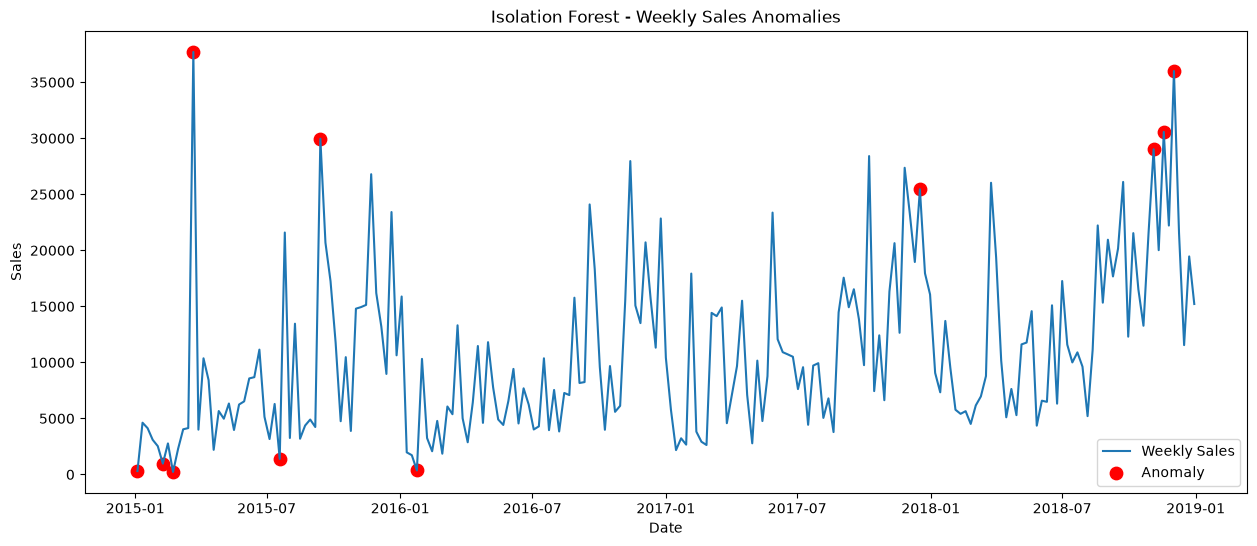

In [26]:

plt.figure(figsize=(15,6))

plt.plot(
    weekly_df["Order Date"],
    weekly_df["Sales"],
    label="Weekly Sales"
)

anomaly = weekly_df[
    weekly_df["Anomaly"]=="Anomaly"
]

plt.scatter(
    anomaly["Order Date"],
    anomaly["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest - Weekly Sales Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

## Possible Real-World Explanations for Detected Anomalies

- High sales spikes in November may correspond to Black Friday and Cyber Monday promotions.
- Sales peaks in December are likely due to Christmas and New Year shopping.
- Higher sales during August or September may reflect back-to-school demand.
- Sales increases in July may result from seasonal discounts or promotional campaigns.
- Lower sales in January may occur because of reduced post-holiday spending.
- Unexpected low-sales weeks may indicate inventory shortages, supply chain issues, or reduced marketing activity.

### ● Calculate Rolling Mean & Standard Deviation

In [27]:


window = 8

weekly_df["Rolling Mean"] = (
    weekly_df["Sales"]
    .rolling(window)
    .mean()
)

weekly_df["Rolling Std"] = (
    weekly_df["Sales"]
    .rolling(window)
    .std()
)

# ● Calculate Z Score

weekly_df["Z Score"] = (
    (weekly_df["Sales"] - weekly_df["Rolling Mean"])
    /
    weekly_df["Rolling Std"]
)

# ● Detect Z Score Anomalies

weekly_df["Z Anomaly"] = np.where(
    abs(weekly_df["Z Score"]) > 2,
    "Anomaly",
    "Normal"
)

### ● Plot Z-Score Anomalies

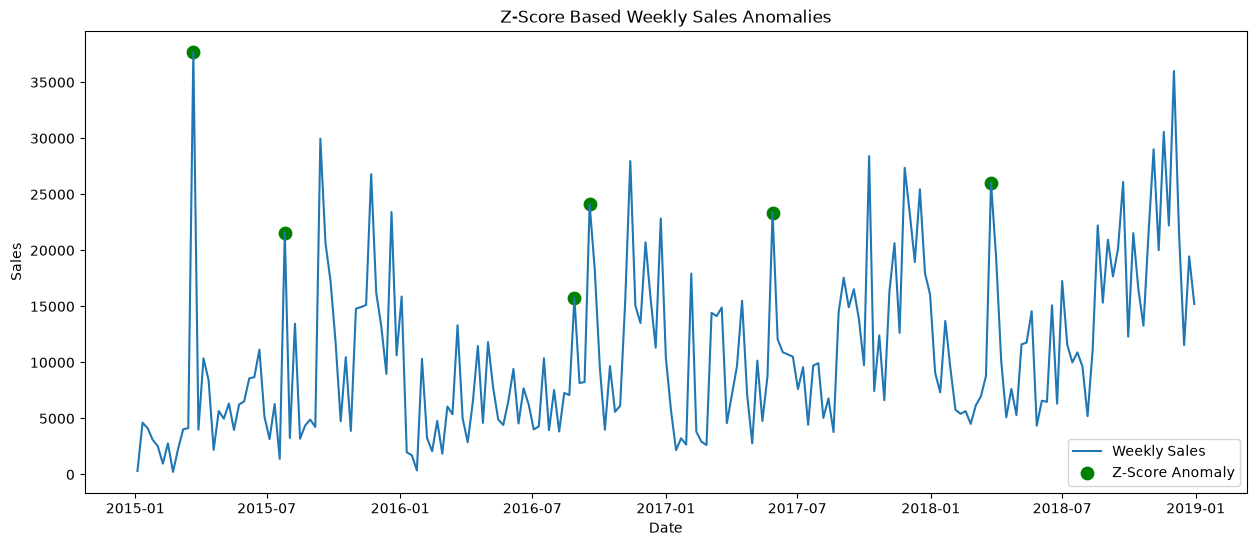

In [28]:


plt.figure(figsize=(15,6))

plt.plot(
    weekly_df["Order Date"],
    weekly_df["Sales"],
    label="Weekly Sales"
)

z = weekly_df[
    weekly_df["Z Anomaly"]=="Anomaly"
]

plt.scatter(
    z["Order Date"],
    z["Sales"],
    color="green",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Based Weekly Sales Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

### ● Compare Both Methods

In [29]:


comparison = weekly_df[
    [
        "Order Date",
        "Sales",
        "Anomaly",
        "Z Anomaly"
    ]
]

comparison.head(20)

,Order Date,Sales,Anomaly,Z Anomaly
0,2015-01-04,304.508,Anomaly,Normal
1,2015-01-11,4619.108,Normal,Normal
2,2015-01-18,4130.533,Normal,Normal
3,2015-01-25,3092.544,Normal,Normal
4,2015-02-01,2527.914,Normal,Normal
5,2015-02-08,968.534,Anomaly,Normal
6,2015-02-15,2771.054,Normal,Normal
7,2015-02-22,224.912,Anomaly,Normal
8,2015-03-01,2289.643,Normal,Normal
9,2015-03-08,4030.728,Normal,Normal


### ● Find Common Anomalies

In [30]:


both = weekly_df[
    (weekly_df["Anomaly"]=="Anomaly") &
    (weekly_df["Z Anomaly"]=="Anomaly")
]

both

,Order Date,Sales,Anomaly,Rolling Mean,Rolling Std,Z Score,Z Anomaly
11,2015-03-22,37703.665,Anomaly,6832.0065,12546.138409,2.46065,Anomaly


### ● Count Anomalies

In [31]:


print(
    "Isolation Forest:",
    sum(weekly_df["Anomaly"]=="Anomaly")
)

print(
    "Z Score:",
    sum(weekly_df["Z Anomaly"]=="Anomaly")
)

print(
    "Common:",
    len(both)
)

Isolation Forest: 11
Z Score: 6
Common: 1


### Isolation Forest

- Isolation Forest identified unusually high and low sales weeks by isolating abnormal observations.

### Z-Score Detection

- Z-Score detected weeks where sales were more than two standard deviations away from the rolling mean.

### Comparison

- Both methods detected several common anomalies, showing agreement on major sales spikes and drops.
- Isolation Forest also identified some additional anomalies that were not detected by the Z-Score method, indicating its ability to capture more complex abnormal patterns.

# ● Task 6 — Product Demand Segmentation using Clustering

In [32]:


# --- Step 1: Prepare Date Features ---
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

print("Step 1: Extracting & Aggregating Features...")

# Total Sales
total_sales = df.groupby("Sub-Category")["Sales"].sum()

# Average Order Value
unique_orders = df.groupby("Sub-Category")["Order ID"].nunique()
aov = total_sales / unique_orders

# Monthly Sales Volatility
monthly_subcat = (
    df.groupby(["Sub-Category", "Year", "Month"])["Sales"]
    .sum()
    .reset_index()
)

volatility = (
    monthly_subcat
    .groupby("Sub-Category")["Sales"]
    .std()
    .fillna(0)
)

# Sales Growth Rate (Latest Year vs Previous Year)
yearly_sales = (
    df.groupby(["Sub-Category", "Year"])["Sales"]
    .sum()
    .unstack(fill_value=0)
)

latest_year = yearly_sales.columns.max()
previous_year = latest_year - 1

yoy_growth = (
    yearly_sales[latest_year] -
    yearly_sales[previous_year]
) / (
    yearly_sales[previous_year] + 1e-5
)

# Final Feature Table
subcat_df = pd.DataFrame({
    "Total_Sales": total_sales,
    "AOV": aov,
    "Volatility": volatility,
    "YoY_Growth": yoy_growth
}).fillna(0)

print(subcat_df.head())

Step 1: Extracting & Aggregating Features...
              Total_Sales         AOV   Volatility  YoY_Growth
Sub-Category                                                  
Accessories   164186.7000  233.884188  2579.994809    0.395482
Appliances    104618.4030  235.627034  1821.621539    0.545645
Art            26705.4100   37.090847   330.488343    0.498255
Binders       200028.7850  154.940964  3848.223648    0.463863
Bookcases     113813.1987  512.672066  2220.405080    0.142674


In [33]:
from sklearn.preprocessing import StandardScaler

# --- Step 2: Scale Features ---

print("Step 2: Scaling Features...")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(subcat_df)

Step 2: Scaling Features...


Step 3: Finding Optimal Number of Clusters...


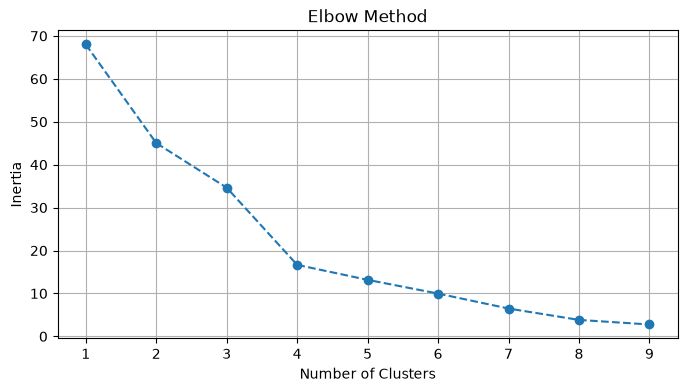

In [34]:
from sklearn.cluster import KMeans
# --- Step 3: Elbow Method ---

print("Step 3: Finding Optimal Number of Clusters...")

inertia = []

for k in range(1,10):
    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(scaled_data)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,4))

plt.plot(
    range(1,10),
    inertia,
    marker="o",
    linestyle="--"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)

plt.show()

In [35]:
# --- Step 4: K-Means Clustering ---

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42
)

subcat_df["Cluster_ID"] = kmeans.fit_predict(
    scaled_data
)

cluster_profiles = (
    subcat_df
    .groupby("Cluster_ID")
    .mean()
)

print(cluster_profiles)

             Total_Sales          AOV   Volatility  YoY_Growth
Cluster_ID                                                    
0           167743.36250  1952.755423  5552.164569    0.068413
1            53715.10614   190.802029  1176.495600   -0.004979
2            76937.30860   121.795872  1196.080178    0.433855
3           254557.59680   418.430704  3670.868329    0.220847


In [36]:
from sklearn.decomposition import PCA
# --- Step 5: PCA Visualization ---

pca = PCA(n_components=2)

pca_data = pca.fit_transform(
    scaled_data
)

subcat_df["PCA1"] = pca_data[:,0]
subcat_df["PCA2"] = pca_data[:,1]

cluster_names = {
    0:"Growing Demand",
    1:"High Volume, Stable",
    2:"Declining Demand",
    3:"Low Volume, High Volatility"
}

subcat_df["Cluster_Label"] = (
    subcat_df["Cluster_ID"]
    .map(cluster_names)
)

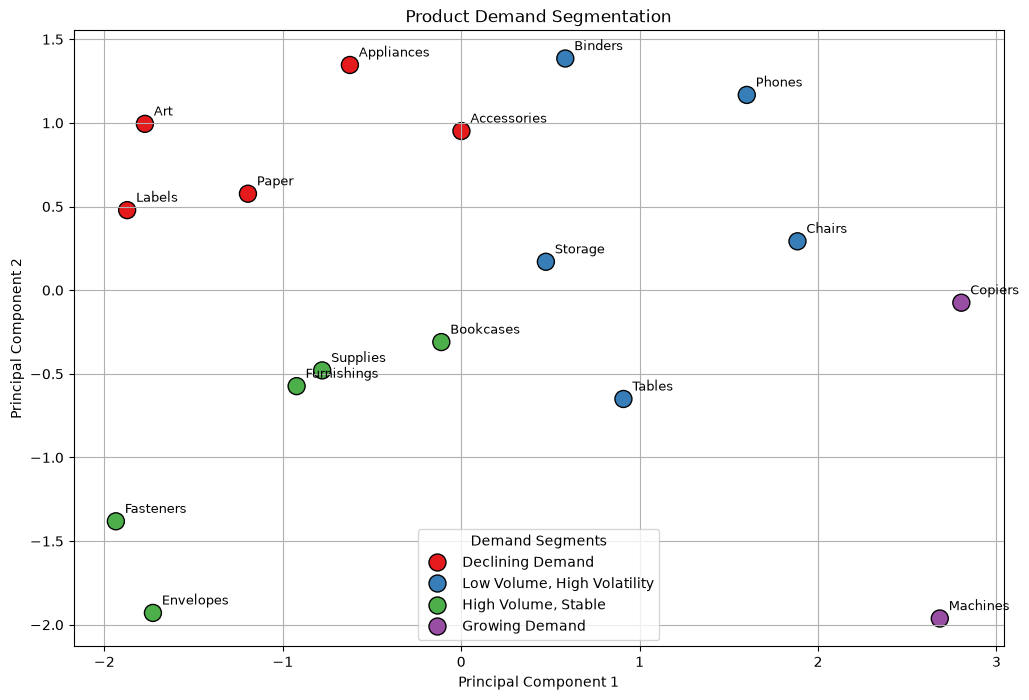

In [37]:
# --- Step 6: Plot Clusters ---

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=subcat_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster_Label",
    palette="Set1",
    s=150,
    edgecolor="black"
)

for item in subcat_df.index:
    plt.text(
        subcat_df.loc[item,"PCA1"]+0.05,
        subcat_df.loc[item,"PCA2"]+0.05,
        item,
        fontsize=9
    )

plt.title("Product Demand Segmentation")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Demand Segments")
plt.grid(True)

plt.show()

### Cluster Analysis & Stocking Strategy Recommendations

#### High Volume, Stable Demand
- Maintain safety stock and automated replenishment.
- Use long-term supplier contracts.

#### Growing Demand
- Increase inventory and warehouse allocation.
- Improve demand forecasting before peak seasons.

#### Low Volume, High Volatility
- Keep limited inventory.
- Prefer on-demand purchasing or drop-shipping.

#### Declining Demand
- Reduce reordering.
- Use discounting and bundling to clear existing inventory.